# Descrierea datelor

* YEAR              --      Anul in care a fost fabricat automobilul
* MAKE              --      Fabricantul automobilului
* MODEL             --      Modelul automobilului
    * 4WD / 4x4 - Four-wheel drive
    * AWD - All-wheel drive
    * CNG - Compressed natural gas
    * FFV - Flexible-fuel vehicle
    * NGV - Natural gas vehicle
    * #- Motor care ofera o putere mai mare decat motorul standard al automobilului
* VEHICLE CLASS     --      Tipul caroseriei automobilului 
* ENGINE SIZE       --      Capacitatea motorului 
* CYLINDERS         --      Numarul de cilindri 
* TRANSMISSION      --      Tipul cutiei de viteze
    * A - Automata
    * AM - Manuala automata
    * AS - Automata cu schimbare selectata
    * AV - Continuu variabila
    * M - Manuala
        * (3 - 10) - Numarul de viteze
* FUEL              --      Tipul combustibilului utilizat de automobil
    * X - Benzina obisnuita
    * Z - Benzina Premium
    * D - Diesel
    * E - Ethanol (E85)
    * N - Gaz Natural
* FUEL CONSUMPTION  --      Consumul de combustibil in oras (L/100 Km)
* HWY               --      Consumul de combustibil pe autostrada (L/100 Km)
* COMB              --      Consumul de combustibil pe autostrata (45%) si in oras (55%) (L/100 Km)
* COMB (mpg)        --      Consumul de combustibil pe autostrada (45%) si in oras (55%) (mile per gallon)
* EMISSIONS         --      Emisiile de CO2 (g/km) estimate la iesirea din teava de esapament, se bazeaza pe tipul de combustibil si consumul combinat

# Ipoteze

* Depinde consumul de cutia de viteze instalata ? (nu este facut)
* Exista o corelatie intre capacitatea motorului si media de consum ? (nu este facut)

* Exista o diferenta de media emisiilor la masinile construite intr-un interval de timp ?  (ok) (7ani) (11ani) (partial -grafic)
* Exista o diferenta intre mediile de consum la diferite clase de masini ? (oras, combinat) (partial -grafic)
* Care dintre clasele de masini (studiate) au cele mai mari emisii ? (partial -grafic)
* Difera emisiile de tipul de carburant ?

# Completare

* inlocuirea unei metode de cautare in dataframe cu citire dintr-o lista ex: [cond,cond,cond,...]
* inlocuirea unei metode cu groupby la cautare in dataframe
* pentru ani --> efectuarea cautarii dupa intervale [2000:2007]

# Implementare Ipoteze

In [1]:
import numpy as np
import pandas as pd
import timeit
import tracemalloc
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("Fuel_Consumption_2000-2022.csv")
dataset.head()

,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,9.2,6.7,8.1,35,186
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,8.5,6.5,7.6,37,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,12.2,7.4,10.0,28,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,13.4,9.2,11.5,25,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,10.0,7.0,8.6,33,198


## Exista o diferenta mare in media emisiilor la masinile construite intr-un interval de timp ?  (ok) (7ani) (11ani)

* Media emisiilor de gaze 7 ani

In [3]:
year_index_dataset = dataset.set_index('YEAR')
print(year_index_dataset.head())
print(len(year_index_dataset.loc[2000:2008]))
print(len(year_index_dataset.loc[2009:2015]))
print(len(year_index_dataset.loc[2016:2022]))

       MAKE    MODEL VEHICLE CLASS  ENGINE SIZE  CYLINDERS TRANSMISSION FUEL  \
YEAR                                                                           
2000  ACURA    1.6EL       COMPACT          1.6          4           A4    X   
2000  ACURA    1.6EL       COMPACT          1.6          4           M5    X   
2000  ACURA    3.2TL      MID-SIZE          3.2          6          AS5    Z   
2000  ACURA    3.5RL      MID-SIZE          3.5          6           A4    Z   
2000  ACURA  INTEGRA    SUBCOMPACT          1.8          4           A4    X   

      FUEL CONSUMPTION  HWY (L/100 km)  COMB (L/100 km)  COMB (mpg)  EMISSIONS  
YEAR                                                                            
2000               9.2             6.7              8.1          35        186  
2000               8.5             6.5              7.6          37        175  
2000              12.2             7.4             10.0          28        230  
2000              13.4            

In [4]:
def ndarray_year_ind_extract_emissions_by_year(begin_year, final_year):
    return np.array(year_index_dataset.loc[begin_year:final_year, 'EMISSIONS'])

def list_extract_emissions_by_year(begin_year, final_year):
    return list(dataset.loc[(dataset['YEAR'] >= begin_year) & (dataset['YEAR'] <= final_year), 'EMISSIONS'])

def ndarray_extract_emissions_by_year(begin_year, final_year):
    return np.array(dataset.loc[(dataset['YEAR'] >= begin_year) & (dataset['YEAR'] <= final_year), 'EMISSIONS'])

def ser_extract_emissions_by_year(begin_year, final_year):
    return dataset.loc[(dataset['YEAR'] >= begin_year) & (dataset['YEAR'] <= final_year), 'EMISSIONS']

In [5]:
def np_mean_ndarray_year_ind_emissions_for_7years():
    np.mean(ndarray_year_ind_extract_emissions_by_year(2000,2008))
    np.mean(ndarray_year_ind_extract_emissions_by_year(2009,2015))
    np.mean(ndarray_year_ind_extract_emissions_by_year(2016,2022))

def np_mean_ndarray_emissions_for_7years():
    np.mean(ndarray_extract_emissions_by_year(2000,2008))
    np.mean(ndarray_extract_emissions_by_year(2009,2015))
    np.mean(ndarray_extract_emissions_by_year(2016,2022))

def my_mean(emission_list):
    return sum(emission_list) / len(emission_list)

def my_mean_list_emissions_for_7years():
    my_mean(list_extract_emissions_by_year(2000,2008))
    my_mean(list_extract_emissions_by_year(2009,2015))
    my_mean(list_extract_emissions_by_year(2016,2022))

def py_mean_ser_emissions_for_7years():
    ser_extract_emissions_by_year(2000,2008).mean()
    ser_extract_emissions_by_year(2009,2015).mean()
    ser_extract_emissions_by_year(2016,2022).mean()

tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ndarray_year_ind_emissions_for_7years()",globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean ndarray indexed year Size: {memory_size} \nNumPy Mean ndarray indexed year Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ndarray_emissions_for_7years()",globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean Size: {memory_size} \nNumPy Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("my_mean_list_emissions_for_7years()",globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python Mean Size: {memory_size} \nPython Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("py_mean_ser_emissions_for_7years()",globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python Ser Mean Size: {memory_size} \nPython Ser Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
tracemalloc.stop()

NumPy Mean ndarray indexed year Size: 16403 
NumPy Mean ndarray indexed year Peak: 144930 
Exec. Time: 0.02850069999999505
----------------------------------------------------------------------------------
NumPy Mean Size: 205507 
NumPy Mean Peak: 421925 
Exec. Time: 0.09760770000002594
----------------------------------------------------------------------------------
Python Mean Size: 8485 
Python Mean Peak: 297760 
Exec. Time: 0.41427520000002005
----------------------------------------------------------------------------------
Python Ser Mean Size: 13867 
Python Ser Mean Peak: 230393 
Exec. Time: 0.11202839999987191


* Grafic

                    0
2001-2007  259.186963
2008-2014  239.244528
2015-2021  251.242787


(220.0, 270.0)

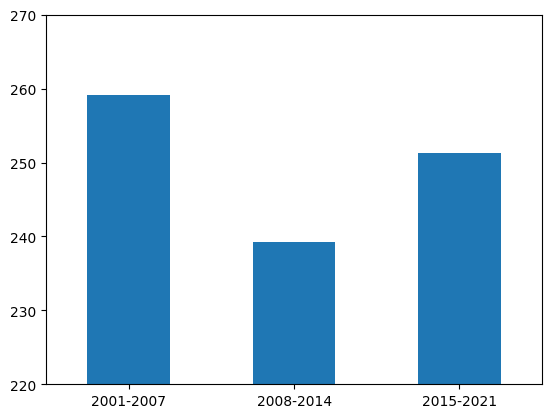

In [6]:
mean_emis_7_years = pd.DataFrame([
    np.mean(ndarray_extract_emissions_by_year(2001,2007)),
    np.mean(ndarray_extract_emissions_by_year(2008,2014)),
    np.mean(ndarray_extract_emissions_by_year(2015,2021))], 
    index=['2001-2007','2008-2014','2015-2021'])

print(mean_emis_7_years)
mean_emis_7_years.plot.bar()
plt.xticks(rotation='horizontal')
plt.legend().remove()
plt.ylim(220,270)

* Media emisiilor de gaze 11 ani

In [7]:
def np_mean_ndarray_year_ind_emissions_for_11years():
    np.mean(ndarray_year_ind_extract_emissions_by_year(2000,2011))
    np.mean(ndarray_year_ind_extract_emissions_by_year(2012,2022))

def np_mean_ndarray_emissions_for_11years():
    np.mean(ndarray_extract_emissions_by_year(2000,2011))
    np.mean(ndarray_extract_emissions_by_year(2012,2022))

def my_mean_list_emissions_for_11years():
    my_mean(list_extract_emissions_by_year(2000,2011))
    my_mean(list_extract_emissions_by_year(2012,2022))

def py_mean_ser_emissions_for_11years():
    ser_extract_emissions_by_year(2000,2011).mean()
    ser_extract_emissions_by_year(2012,2022).mean()

tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ndarray_year_ind_emissions_for_11years()",globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean ndarray indexed year Size: {memory_size} \nNumPy Mean ndarray indexed year Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ndarray_emissions_for_11years()",globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean ndarray Size: {memory_size} \nNumPy Mean ndarray Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("my_mean_list_emissions_for_11years()",globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"my Mean List Size: {memory_size} \nmy Mean List Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("py_mean_ser_emissions_for_11years()",globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python Mean Ser Size: {memory_size} \nPython Mean Ser Peak: {memory_peak} \nExec. Time: {exec_time}")
tracemalloc.stop()

NumPy Mean ndarray indexed year Size: 4571 
NumPy Mean ndarray indexed year Peak: 164555 
Exec. Time: 0.008913800000073024
----------------------------------------------------------------------------------
NumPy Mean ndarray Size: 4258 
NumPy Mean ndarray Peak: 307341 
Exec. Time: 0.04265450000002602
----------------------------------------------------------------------------------
my Mean List Size: 5246 
my Mean List Peak: 411454 
Exec. Time: 0.36745859999996355
----------------------------------------------------------------------------------
Python Mean Ser Size: 5822 
Python Mean Ser Peak: 308901 
Exec. Time: 0.05102329999999711


* grafic

                    0
2000-2010  256.167534
2011-2021  243.986469


(220.0, 270.0)

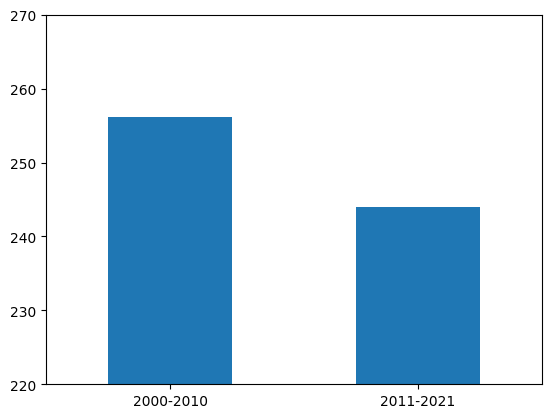

In [8]:
mean_emis_11_years = pd.DataFrame([
    np.mean(ndarray_extract_emissions_by_year(2000,2010)),
    np.mean(ndarray_extract_emissions_by_year(2011,2021))], 
    index=['2000-2010','2011-2021'])

print(mean_emis_11_years)
mean_emis_11_years.plot.bar()
plt.xticks(rotation='horizontal')
plt.legend().remove()
plt.ylim(220,270)

* Suma emisiilor de gaze 7 ani

In [9]:
def np_sum_ndarray_year_ind_emissions_for_7years():
    np.sum(ndarray_year_ind_extract_emissions_by_year(2000,2007))
    np.sum(ndarray_year_ind_extract_emissions_by_year(2008,2014))
    np.sum(ndarray_year_ind_extract_emissions_by_year(2015,2022))

def np_sum_ndarray_emissions_for_7years():
    np.sum(ndarray_extract_emissions_by_year(2000,2007))
    np.sum(ndarray_extract_emissions_by_year(2008,2014))
    np.sum(ndarray_extract_emissions_by_year(2015,2022))

def py_sum_list_emissions_for_7years():
    sum(list_extract_emissions_by_year(2000,2007))
    sum(list_extract_emissions_by_year(2008,2014))
    sum(list_extract_emissions_by_year(2015,2022))

tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_ndarray_year_ind_emissions_for_7years()",globals=globals(),number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Sum for Indexed Year Size: {memory_size} \nNumPy for Indexed Year Sum Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_ndarray_emissions_for_7years()",globals=globals(),number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Sum Size: {memory_size} \nNumPy Sum Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("py_sum_list_emissions_for_7years()",globals=globals(),number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python Sum Size: {memory_size} \nPython Sum Peak: {memory_peak} \nExec. Time: {exec_time}")
tracemalloc.stop()

NumPy Sum for Indexed Year Size: 1533 
NumPy for Indexed Year Sum Peak: 69863 
Exec. Time: 0.0019207999998798186
----------------------------------------------------------------------------------
NumPy Sum Size: 2702 
NumPy Sum Peak: 229487 
Exec. Time: 0.008139799999980823
----------------------------------------------------------------------------------
Python Sum Size: 2382 
Python Sum Peak: 307232 
Exec. Time: 0.03442360000008193


* grafic

                 0
2001-2007  1598406
2008-2014  1781654
2015-2021  1846132


(1500000.0, 1870000.0)

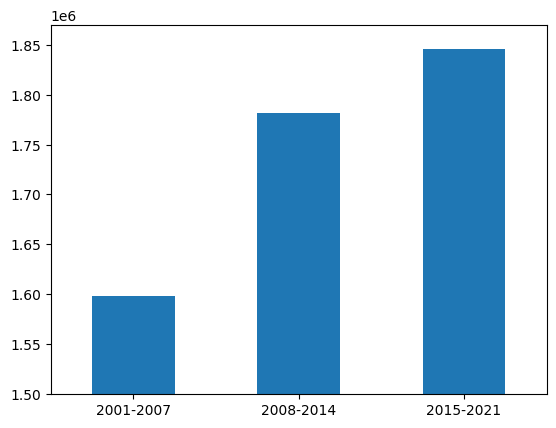

In [10]:
sum_emis_7_years = pd.DataFrame([
    np.sum(ndarray_extract_emissions_by_year(2001,2007)),
    np.sum(ndarray_extract_emissions_by_year(2008,2014)),
    np.sum(ndarray_extract_emissions_by_year(2015,2021))], 
    index=['2001-2007','2008-2014','2015-2021'])

print(sum_emis_7_years)
sum_emis_7_years.plot.bar()
plt.xticks(rotation='horizontal')
plt.legend().remove()
plt.ylim(1500000,1870000)

* Suma emisiilor de gaze 11 ani

In [11]:
def np_sum_ndarray_year_ind_emissions_for_11years():
    np.sum(ndarray_year_ind_extract_emissions_by_year(2000,2011))
    np.sum(ndarray_year_ind_extract_emissions_by_year(2012,2021))

def np_sum_ndarray_emissions_for_11years():
    np.sum(ndarray_extract_emissions_by_year(2000,2011))
    np.sum(ndarray_extract_emissions_by_year(2012,2021))

def py_sum_ndarray_emissions_for_11years():
    sum(list_extract_emissions_by_year(2000,2011))
    sum(list_extract_emissions_by_year(2012,2021))

tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_ndarray_year_ind_emissions_for_11years()",globals=globals(),number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Sum for Indexed Year Size: {memory_size} \nNumPy Sum for Indexed Year Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_ndarray_emissions_for_11years()",globals=globals(),number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Sum Size: {memory_size} \nNumPy Sum Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("py_sum_ndarray_emissions_for_11years()",globals=globals(),number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python Sum Size: {memory_size} \nPython Sum Peak: {memory_peak} \nExec. Time: {exec_time}")
tracemalloc.stop()

NumPy Sum for Indexed Year Size: 996 
NumPy Sum for Indexed Year Peak: 91976 
Exec. Time: 0.0020099999999274587
----------------------------------------------------------------------------------
NumPy Sum Size: 2230 
NumPy Sum Peak: 294544 
Exec. Time: 0.004220799999984592
----------------------------------------------------------------------------------
Python Sum Size: 1769 
Python Sum Peak: 400651 
Exec. Time: 0.03244530000006307


* grafic

11074
11482
                 0
2000-2011  2819548
2012-2022  2820996


(2815000.0, 2825000.0)

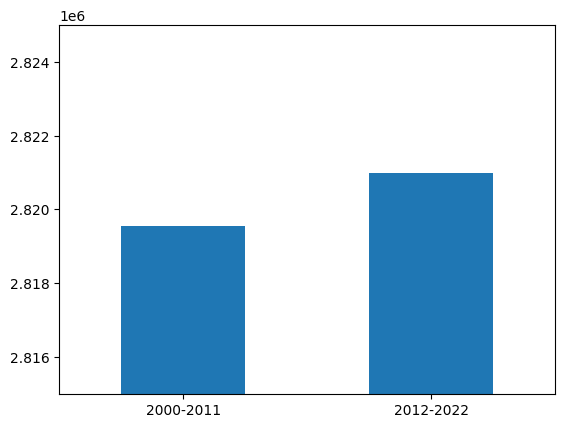

In [12]:
sum_emis_11_years = pd.DataFrame([
    np.sum(ndarray_extract_emissions_by_year(2000,2011)),
    np.sum(ndarray_extract_emissions_by_year(2012,2022))], 
    index=['2000-2011','2012-2022'])


print(len(ndarray_extract_emissions_by_year(2000,2011)))
print(len(ndarray_extract_emissions_by_year(2012,2022)))
print(sum_emis_11_years)
sum_emis_11_years.plot.bar()
plt.xticks(rotation='horizontal')
plt.legend().remove()
plt.ylim(2815000,2825000)

## Exista o diferenta mare intre mediile de consum la diferite clase de masini ? (oras, combinat)

* Prelucrarea (inlocuire notatiilor neconvenabile) claselor de masini

In [15]:
preproc_dataset = dataset
preproc_dataset['VEHICLE CLASS'] = preproc_dataset['VEHICLE CLASS'].replace(['Two-seater'], 'TWO-SEATER')
preproc_dataset['VEHICLE CLASS'] = preproc_dataset['VEHICLE CLASS'].replace(['Compact', 'MINICOMPACT', 'Minicompact', 'SUBCOMPACT', 'Subcompact'], 'COMPACT')
preproc_dataset['VEHICLE CLASS'] = preproc_dataset['VEHICLE CLASS'].replace(['Mid-size', 'FULL-SIZE', 'Full-size', 'STATION WAGON - MID-SIZE', 
                                                                             'Station wagon: Mid-size', 'STATION WAGON - SMALL', 'Station wagon: Small'], 'MID-SIZE')
preproc_dataset['VEHICLE CLASS'] = preproc_dataset['VEHICLE CLASS'].replace(['Suv', 'SUV - SMALL', 'SUV: Small', 'SUV - STANDARD', 'SUV: Standard'], 'SUV')
preproc_dataset['VEHICLE CLASS'] = preproc_dataset['VEHICLE CLASS'].replace(['VAN - CARGO', 'VAN - PASSENGER', 'Van: Passenger', 'Minivan', 'MINIVAN'], 'VAN')
preproc_dataset['VEHICLE CLASS'] = preproc_dataset['VEHICLE CLASS'].replace(['PICKUP TRUCK - SMALL', 'Pickup truck: Small', 'PICKUP TRUCK - STANDARD',
                                                                              'Pickup truck: Standard'], 'PICKUP TRUCK')
preproc_dataset['VEHICLE CLASS'] = preproc_dataset['VEHICLE CLASS'].replace(['Special purpose vehicle'], 'SPECIAL PURPOSE VEHICLE')


* Group By Vehicle Class

In [34]:
def ser_group_by_vehicle_class(need_column, vehicle_class):
    return preproc_dataset.groupby('VEHICLE CLASS')[need_column].get_group(vehicle_class)

def ndarray_group_by_vehicle_class(need_column, vehicle_class):
    return np.array(preproc_dataset.groupby('VEHICLE CLASS')[need_column].get_group(vehicle_class))

29       10.9
30       11.6
51       12.4
59       17.4
209      22.4
         ... 
22374    14.0
22375    13.0
22376    14.0
22501     9.3
22502    10.6
Name: FUEL CONSUMPTION, Length: 1312, dtype: float64


* Media carburantului consumat in functie de clasele de masini (oras)

In [17]:
def ser_pandas_isin_two_seater_cars(need_column):
    options = ['TWO-SEATER','Two-seater']
    return dataset.loc[(dataset['VEHICLE CLASS'].isin(options)), need_column]

def ser_pandas_isin_compact_cars(need_column):
    options = ['COMPACT', 'Compact', 'MINICOMPACT', 'Minicompact', 'SUBCOMPACT', 'Subcompact']
    return dataset.loc[(dataset['VEHICLE CLASS'].isin(options)), need_column]

def ser_pandas_isin_mid_sized_cars(need_column):
    options = ['MID-SIZE', 'Mid-size', 'FULL-SIZE', 'Full-size', 'STATION WAGON - MID-SIZE', 'Station wagon: Mid-size', 'STATION WAGON - SMALL', 'Station wagon: Small']
    return dataset.loc[(dataset['VEHICLE CLASS'].isin(options)), need_column]

def ser_pandas_isin_suv_cars(need_column):
    options = ['SUV', 'Suv', 'SUV - SMALL', 'SUV: Small', 'SUV - STANDARD', 'SUV: Standard']
    return dataset.loc[(dataset['VEHICLE CLASS'].isin(options)), need_column]

def ser_pandas_isin_van_cars(need_column):
    options = ['VAN - CARGO', 'VAN - PASSENGER', 'Van: Passenger', 'Minivan', 'MINIVAN']
    return dataset.loc[(dataset['VEHICLE CLASS'].isin(options)), need_column]

def ser_pandas_isin_pickup_cars(need_column):
    options = ['PICKUP TRUCK - SMALL', 'Pickup truck: Small', 'PICKUP TRUCK - STANDARD', 'Pickup truck: Standard']
    return dataset.loc[(dataset['VEHICLE CLASS'].isin(options)), need_column]

def ser_pandas_isin_spec_cars(need_column):
    options = ['SPECIAL PURPOSE VEHICLE', 'Special purpose vehicle']
    return dataset.loc[(dataset['VEHICLE CLASS'].isin(options)), need_column]

In [18]:
def ndarray_match_two_seater_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'] == 'TWO-SEATER') | (dataset['VEHICLE CLASS'] == 'Two-seater'), need_column])

def ndarray_match_compact_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS']=='COMPACT') | (dataset['VEHICLE CLASS'] == 'Compact') |
                                (dataset['VEHICLE CLASS']=='MINICOMPACT') | (dataset['VEHICLE CLASS'] == 'Minicompact') |
                                (dataset['VEHICLE CLASS']=='SUBCOMPACT') | (dataset['VEHICLE CLASS'] == 'Subcompact'), need_column])

def ndarray_match_mid_sized_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'] == 'MID-SIZE') | (dataset['VEHICLE CLASS'] == 'Mid-size') |
                                (dataset['VEHICLE CLASS'] == 'FULL-SIZE') | (dataset['VEHICLE CLASS'] == 'Full-size') |
                                (dataset['VEHICLE CLASS'] == 'STATION WAGON - MID-SIZE') | (dataset['VEHICLE CLASS'] == 'Station wagon: Mid-size') |
                                (dataset['VEHICLE CLASS'] == 'STATION WAGON - SMALL') | (dataset['VEHICLE CLASS'] == 'Station wagon: Small'),
                                  need_column])

def ndarray_match_suv_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'] == 'SUV') | (dataset['VEHICLE CLASS'] == 'Suv') |
                                (dataset['VEHICLE CLASS'] == 'SUV - SMALL') | (dataset['VEHICLE CLASS'] == 'SUV: Small') |
                                (dataset['VEHICLE CLASS'] == 'SUV - STANDARD') | ((dataset['VEHICLE CLASS'] == 'SUV: Standard'))
                                , need_column])

def ndarray_match_van_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'] == 'VAN - CARGO') | (dataset['VEHICLE CLASS'] == 'VAN - PASSENGER') |
                                (dataset['VEHICLE CLASS'] == 'Van: Passenger') | (dataset['VEHICLE CLASS'] == 'Minivan') |
                                (dataset['VEHICLE CLASS'] == 'MINIVAN')
                                , need_column])

def ndarray_match_pickup_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'] == 'PICKUP TRUCK - SMALL') | (dataset['VEHICLE CLASS'] == 'Pickup truck: Small') |
                                (dataset['VEHICLE CLASS'] == 'PICKUP TRUCK - STANDARD') | (dataset['VEHICLE CLASS'] == 'Pickup truck: Standard')
                                , need_column])

def ndarray_match_spec_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'] == 'SPECIAL PURPOSE VEHICLE') | (dataset['VEHICLE CLASS'] == 'Special purpose vehicle')
                                , need_column])

In [19]:
def ndarray_two_seater_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('TWO-SEATER')) | 
                                 (dataset['VEHICLE CLASS'].str.contains('Two-seater')), need_column])

def ndarray_compact_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('COMPACT')) | 
                                (dataset['VEHICLE CLASS'].str.contains('compact')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Compact')), need_column])

def ndarray_mid_sized_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('MID-SIZE')) |
                                (dataset['VEHICLE CLASS'].str.contains('FULL-SIZE')) |
                                (dataset['VEHICLE CLASS'].str.contains('Mid-size')) |
                                (dataset['VEHICLE CLASS'].str.contains('Full-size')) |
                                (dataset['VEHICLE CLASS'].str.contains('STATION WAGON')) |
                                (dataset['VEHICLE CLASS'].str.contains('Station wagon')), need_column])

def ndarray_suv_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('SUV')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Suv')), need_column])

def ndarray_van_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('VAN')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Van')) |
                                (dataset['VEHICLE CLASS'].str.contains('van')), need_column])

def ndarray_pickup_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('PICKUP TRUCK')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Pickup truck')), need_column])

def ndarray_spec_cars(need_column):
    return np.array(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('SPECIAL PURPOSE VEHICLE')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Special purpose vehicle')), need_column])

In [20]:
def ser_two_seater_cars(need_column):
    return (dataset.loc[(dataset['VEHICLE CLASS'] == 'TWO-SEATER') | (dataset['VEHICLE CLASS'] == 'Two-seater'), need_column])

def ser_compact_cars(need_column):
    return (dataset.loc[(dataset['VEHICLE CLASS'].str.contains('COMPACT')) | 
                                (dataset['VEHICLE CLASS'].str.contains('compact')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Compact')), need_column])

def ser_mid_sized_cars(need_column):
    return (dataset.loc[(dataset['VEHICLE CLASS'].str.contains('MID-SIZE')) |
                                (dataset['VEHICLE CLASS'].str.contains('FULL-SIZE')) |
                                (dataset['VEHICLE CLASS'].str.contains('Mid-size')) |
                                (dataset['VEHICLE CLASS'].str.contains('Full-size')) |
                                (dataset['VEHICLE CLASS'].str.contains('STATION WAGON')) |
                                (dataset['VEHICLE CLASS'].str.contains('Station wagon')), need_column])

def ser_suv_cars(need_column):
    return (dataset.loc[(dataset['VEHICLE CLASS'].str.contains('SUV')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Suv')), need_column])

def ser_van_cars(need_column):
    return (dataset.loc[(dataset['VEHICLE CLASS'].str.contains('VAN')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Van')) |
                                (dataset['VEHICLE CLASS'].str.contains('van')), need_column])

def ser_pickup_cars(need_column):
    return (dataset.loc[(dataset['VEHICLE CLASS'].str.contains('PICKUP TRUCK')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Pickup truck')), need_column])

def ser_spec_cars(need_column):
    return (dataset.loc[(dataset['VEHICLE CLASS'].str.contains('SPECIAL PURPOSE VEHICLE')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Special purpose vehicle')), need_column])

In [21]:
def list_two_seater_cars(need_column):
    return list(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('TWO-SEATER')) | 
                            (dataset['VEHICLE CLASS'].str.contains('Two-seater')), need_column])

def list_compact_cars(need_column):
    return list(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('COMPACT')) | 
                                (dataset['VEHICLE CLASS'].str.contains('compact')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Compact')), need_column])

def list_mid_sized_cars(need_column):
    return list(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('MID-SIZE')) |
                                (dataset['VEHICLE CLASS'].str.contains('FULL-SIZE')) |
                                (dataset['VEHICLE CLASS'].str.contains('Mid-size')) |
                                (dataset['VEHICLE CLASS'].str.contains('Full-size')) |
                                (dataset['VEHICLE CLASS'].str.contains('STATION WAGON')) |
                                (dataset['VEHICLE CLASS'].str.contains('Station wagon')), need_column])

def list_suv_cars(need_column):
    return list(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('SUV')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Suv')), need_column])

def list_van_cars(need_column):
    return list(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('VAN')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Van')) |
                                (dataset['VEHICLE CLASS'].str.contains('van')), need_column])

def list_pickup_cars(need_column):
    return list(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('PICKUP TRUCK')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Pickup truck')), need_column])

def list_spec_cars(need_column):
    return list(dataset.loc[(dataset['VEHICLE CLASS'].str.contains('SPECIAL PURPOSE VEHICLE')) | 
                                (dataset['VEHICLE CLASS'].str.contains('Special purpose vehicle')), need_column])

In [107]:
def np_mean_ndarray_groupby_consum():
    np.mean(ndarray_group_by_vehicle_class('FUEL CONSUMPTION', 'TWO-SEATER'))
    np.mean(ndarray_group_by_vehicle_class('FUEL CONSUMPTION', 'COMPACT'))
    np.mean(ndarray_group_by_vehicle_class('FUEL CONSUMPTION', 'MID-SIZE'))
    np.mean(ndarray_group_by_vehicle_class('FUEL CONSUMPTION', 'SUV'))
    np.mean(ndarray_group_by_vehicle_class('FUEL CONSUMPTION', 'VAN'))
    np.mean(ndarray_group_by_vehicle_class('FUEL CONSUMPTION', 'PICKUP TRUCK'))
    np.mean(ndarray_group_by_vehicle_class('FUEL CONSUMPTION', 'SPECIAL PURPOSE VEHICLE'))

def np_mean_ser_groupby_consum():
    np.mean(ser_group_by_vehicle_class('FUEL CONSUMPTION', 'TWO-SEATER'))
    np.mean(ser_group_by_vehicle_class('FUEL CONSUMPTION', 'COMPACT'))
    np.mean(ser_group_by_vehicle_class('FUEL CONSUMPTION', 'MID-SIZE'))
    np.mean(ser_group_by_vehicle_class('FUEL CONSUMPTION', 'SUV'))
    np.mean(ser_group_by_vehicle_class('FUEL CONSUMPTION', 'VAN'))
    np.mean(ser_group_by_vehicle_class('FUEL CONSUMPTION', 'PICKUP TRUCK'))
    np.mean(ser_group_by_vehicle_class('FUEL CONSUMPTION', 'SPECIAL PURPOSE VEHICLE'))

def np_mean_ser_pandas_isin_consum_clase_oras(): # cu serii
    np.mean(ser_pandas_isin_two_seater_cars('FUEL CONSUMPTION'))
    np.mean(ser_pandas_isin_compact_cars('FUEL CONSUMPTION'))
    np.mean(ser_pandas_isin_mid_sized_cars('FUEL CONSUMPTION'))
    np.mean(ser_pandas_isin_suv_cars('FUEL CONSUMPTION'))
    np.mean(ser_pandas_isin_van_cars('FUEL CONSUMPTION'))
    np.mean(ser_pandas_isin_pickup_cars('FUEL CONSUMPTION'))
    np.mean(ser_pandas_isin_spec_cars('FUEL CONSUMPTION'))

def np_match_mean_consum_clase_oras(): # cu ndarray
    np.mean(ndarray_match_two_seater_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_match_compact_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_match_mid_sized_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_match_suv_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_match_van_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_match_pickup_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_match_spec_cars('FUEL CONSUMPTION'))

def np_mean_consum_clase_oras(): # cu ndarray
    np.mean(ndarray_two_seater_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_compact_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_mid_sized_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_suv_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_van_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_pickup_cars('FUEL CONSUMPTION'))
    np.mean(ndarray_spec_cars('FUEL CONSUMPTION'))

def np_my_mean_consum_clase_oras(): # cu ndarray
    my_mean(ndarray_two_seater_cars('FUEL CONSUMPTION'))
    my_mean(ndarray_compact_cars('FUEL CONSUMPTION'))
    my_mean(ndarray_mid_sized_cars('FUEL CONSUMPTION'))
    my_mean(ndarray_suv_cars('FUEL CONSUMPTION'))
    my_mean(ndarray_van_cars('FUEL CONSUMPTION'))
    my_mean(ndarray_pickup_cars('FUEL CONSUMPTION'))
    my_mean(ndarray_spec_cars('FUEL CONSUMPTION'))

def my_mean_consum_clase_oras(): # cu serii
    my_mean(ser_two_seater_cars('FUEL CONSUMPTION'))
    my_mean(ser_compact_cars('FUEL CONSUMPTION'))
    my_mean(ser_mid_sized_cars('FUEL CONSUMPTION'))
    my_mean(ser_suv_cars('FUEL CONSUMPTION'))
    my_mean(ser_van_cars('FUEL CONSUMPTION'))
    my_mean(ser_pickup_cars('FUEL CONSUMPTION'))
    my_mean(ser_spec_cars('FUEL CONSUMPTION'))

def list_my_mean_consum_clase_oras(): # cu liste
    my_mean(list_two_seater_cars('FUEL CONSUMPTION'))
    my_mean(list_compact_cars('FUEL CONSUMPTION'))
    my_mean(list_mid_sized_cars('FUEL CONSUMPTION'))
    my_mean(list_suv_cars('FUEL CONSUMPTION'))
    my_mean(list_van_cars('FUEL CONSUMPTION'))
    my_mean(list_pickup_cars('FUEL CONSUMPTION'))
    my_mean(list_spec_cars('FUEL CONSUMPTION'))

tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ndarray_groupby_consum()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean NDArray GroupBy Size: {memory_size} \nNumPy Mean NDArray GroupBy Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ser_groupby_consum()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean Ser GroupBy Size: {memory_size} \nNumPy Mean Ser GroupBy Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_consum_clase_oras()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean Size: {memory_size} \nNumPy Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("my_mean_consum_clase_oras()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python Ser Mean Size: {memory_size} \nPython Ser Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_my_mean_consum_clase_oras()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python NDArray Mean Size: {memory_size} \nPython NDArray Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("list_my_mean_consum_clase_oras()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python List Mean Size: {memory_size} \nPython List Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_match_mean_consum_clase_oras()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Numpy Match Mean Size: {memory_size} \nNumpy Match Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_match_mean_consum_clase_oras()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Numpy Mean Ser Pandas isin Size: {memory_size} \nNumpy Mean Ser Pandas isin Peak: {memory_peak} \nExec. Time: {exec_time}")
tracemalloc.stop()

NumPy Mean NDArray GroupBy Size: 6834 
NumPy Mean NDArray GroupBy Peak: 912690 
Exec. Time: 0.03514170000562444
----------------------------------------------------------------------------------
NumPy Mean Ser GroupBy Size: 6459 
NumPy Mean Ser GroupBy Peak: 912143 
Exec. Time: 0.06393679999746382
----------------------------------------------------------------------------------
NumPy Mean Size: 2882 
NumPy Mean Peak: 1180839 
Exec. Time: 0.666868299987982
----------------------------------------------------------------------------------
Python Ser Mean Size: 2692 
Python Ser Mean Peak: 1180633 
Exec. Time: 0.5688711999973748
----------------------------------------------------------------------------------
Python NDArray Mean Size: 2648 
Python NDArray Mean Peak: 1182835 
Exec. Time: 0.5627180000010412
----------------------------------------------------------------------------------
Python List Mean Size: 5384 
Python List Mean Peak: 1184274 
Exec. Time: 0.5754869999946095
----------

c:\Users\colit\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\colit\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


* grafic

                        0
two-seater      13.938796
compact cars    11.232115
mid-sized cars  11.787480
suv cars        13.279050
van cars              NaN
pickup cars           NaN
spec cars       11.644737


(10.0, 17.0)

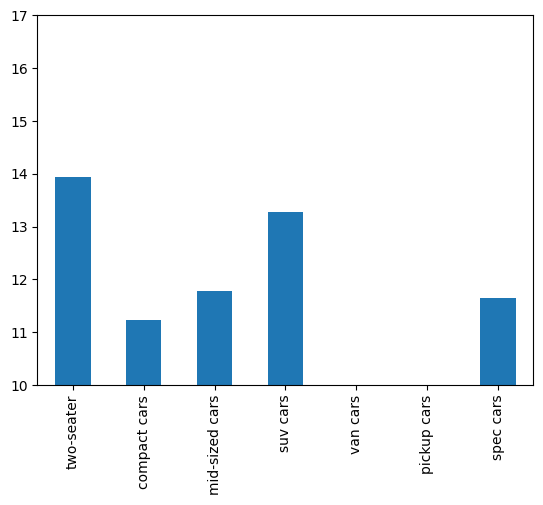

In [27]:
cons_oras = pd.DataFrame([
    np.mean(ser_pandas_isin_two_seater_cars('FUEL CONSUMPTION')),
    np.mean(ser_pandas_isin_compact_cars('FUEL CONSUMPTION')),
    np.mean(ser_pandas_isin_mid_sized_cars('FUEL CONSUMPTION')),
    np.mean(ser_pandas_isin_suv_cars('FUEL CONSUMPTION')),
    np.mean(ser_pandas_isin_van_cars('FUEL CONSUMPTION')),
    np.mean(ser_pandas_isin_pickup_cars('FUEL CONSUMPTION')),
    np.mean(ser_pandas_isin_spec_cars('FUEL CONSUMPTION'))], 
    index=['two-seater', 'compact cars', 'mid-sized cars', 'suv cars', 'van cars', 'pickup cars', 'spec cars'])

print(cons_oras)
cons_oras.plot.bar()
plt.legend().remove()
plt.ylim(10,17)


* Media carburant consumat combinat

In [42]:
def np_mean_ndarray_groupby_consum():
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'TWO-SEATER'))
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'COMPACT'))
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'MID-SIZE'))
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'SUV'))
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'VAN'))
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'PICKUP TRUCK'))
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'SPECIAL PURPOSE VEHICLE'))

def np_mean_ser_groupby_consum():
    np.mean(ser_group_by_vehicle_class('COMB (L/100 km)', 'TWO-SEATER'))
    np.mean(ser_group_by_vehicle_class('COMB (L/100 km)', 'COMPACT'))
    np.mean(ser_group_by_vehicle_class('COMB (L/100 km)', 'MID-SIZE'))
    np.mean(ser_group_by_vehicle_class('COMB (L/100 km)', 'SUV'))
    np.mean(ser_group_by_vehicle_class('COMB (L/100 km)', 'VAN'))
    np.mean(ser_group_by_vehicle_class('COMB (L/100 km)', 'PICKUP TRUCK'))
    np.mean(ser_group_by_vehicle_class('COMB (L/100 km)', 'SPECIAL PURPOSE VEHICLE'))

def np_mean_ser_pandas_isin_consum_clase_oras(): # cu ndarray
    np.mean(ser_pandas_isin_two_seater_cars('COMB (L/100 km)'))
    np.mean(ser_pandas_isin_compact_cars('COMB (L/100 km)'))
    np.mean(ser_pandas_isin_mid_sized_cars('COMB (L/100 km)'))
    np.mean(ser_pandas_isin_suv_cars('COMB (L/100 km)'))
    np.mean(ser_pandas_isin_van_cars('COMB (L/100 km)'))
    np.mean(ser_pandas_isin_pickup_cars('COMB (L/100 km)'))
    np.mean(ser_pandas_isin_spec_cars('COMB (L/100 km)'))

def np_mean_ndarray_consum_clase_oras(): # cu ndarray
    np.mean(ndarray_two_seater_cars('COMB (L/100 km)'))
    np.mean(ndarray_compact_cars('COMB (L/100 km)'))
    np.mean(ndarray_mid_sized_cars('COMB (L/100 km)'))
    np.mean(ndarray_suv_cars('COMB (L/100 km)'))
    np.mean(ndarray_van_cars('COMB (L/100 km)'))
    np.mean(ndarray_pickup_cars('COMB (L/100 km)'))
    np.mean(ndarray_spec_cars('COMB (L/100 km)'))

def my_mean_ndarray_consum_clase_oras(): # cu ndarray
    my_mean(ndarray_two_seater_cars('COMB (L/100 km)'))
    my_mean(ndarray_compact_cars('COMB (L/100 km)'))
    my_mean(ndarray_mid_sized_cars('COMB (L/100 km)'))
    my_mean(ndarray_suv_cars('COMB (L/100 km)'))
    my_mean(ndarray_van_cars('COMB (L/100 km)'))
    my_mean(ndarray_pickup_cars('COMB (L/100 km)'))
    my_mean(ndarray_spec_cars('COMB (L/100 km)'))

def py_mean_consum_clase_oras(): # cu ndarray
    ndarray_two_seater_cars('COMB (L/100 km)').mean()
    ndarray_compact_cars('COMB (L/100 km)').mean()
    ndarray_mid_sized_cars('COMB (L/100 km)').mean()
    ndarray_suv_cars('COMB (L/100 km)').mean()
    ndarray_van_cars('COMB (L/100 km)').mean()
    ndarray_pickup_cars('COMB (L/100 km)').mean()
    ndarray_spec_cars('COMB (L/100 km)').mean()

def my_mean_consum_clase_oras(): # cu serii
    my_mean(ser_two_seater_cars('COMB (L/100 km)'))
    my_mean(ser_compact_cars('COMB (L/100 km)'))
    my_mean(ser_mid_sized_cars('COMB (L/100 km)'))
    my_mean(ser_suv_cars('COMB (L/100 km)'))
    my_mean(ser_van_cars('COMB (L/100 km)'))
    my_mean(ser_pickup_cars('COMB (L/100 km)'))
    my_mean(ser_spec_cars('COMB (L/100 km)'))


tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ndarray_groupby_consum()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean NDArray GroupBy Size: {memory_size} \nNumPy Mean NDArray GroupBy Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ser_groupby_consum()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean Ser GroupBy Size: {memory_size} \nNumPy Mean Ser GroupBy Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ser_pandas_isin_consum_clase_oras()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean Ser Pandas isin Size: {memory_size} \nNumPy Mean Ser Pandas isin Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_consum_clase_oras()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean Size: {memory_size} \nNumPy Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("my_mean_consum_clase_oras()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python my Mean Size: {memory_size} \nPython my Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("my_mean_ndarray_consum_clase_oras()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python ndarray Mean Size: {memory_size} \nPython ndarray Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("py_mean_consum_clase_oras()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python ndarray Mean Size: {memory_size} \nPython ndarray Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
tracemalloc.stop()

NumPy Mean NDArray GroupBy Size: 4177 
NumPy Mean NDArray GroupBy Peak: 910537 
Exec. Time: 0.05191589999594726
----------------------------------------------------------------------------------
NumPy Mean Ser GroupBy Size: 5122 
NumPy Mean Ser GroupBy Peak: 911078 
Exec. Time: 0.06272630000603385
----------------------------------------------------------------------------------
NumPy Mean Ser Pandas isin Size: 3227 
NumPy Mean Ser Pandas isin Peak: 176922 
Exec. Time: 0.04478340000787284
----------------------------------------------------------------------------------
NumPy Mean Size: 2656 
NumPy Mean Peak: 1180717 
Exec. Time: 0.6226133000018308
----------------------------------------------------------------------------------
Python my Mean Size: 3134 
Python my Mean Peak: 1181179 
Exec. Time: 0.5737023999972735
----------------------------------------------------------------------------------
Python ndarray Mean Size: 2232 
Python ndarray Mean Peak: 1181882 
Exec. Time: 0.62498870

* grafic

                        0
two-seater      11.835823
compact cars     9.640450
mid-sized cars  10.065060
suv cars        11.642950
van cars        14.339557
pickup cars     13.359337
spec cars       10.514035


(9.0, 15.0)

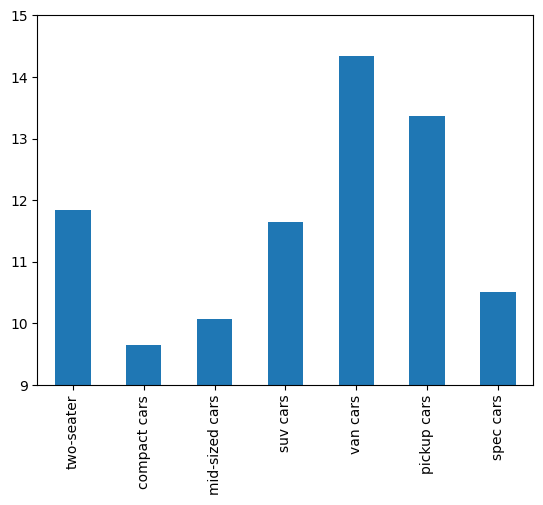

In [44]:
cons_comb = pd.DataFrame(
    [np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'TWO-SEATER')),
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'COMPACT')),
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'MID-SIZE')),
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'SUV')),
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'VAN')),
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'PICKUP TRUCK')),
    np.mean(ndarray_group_by_vehicle_class('COMB (L/100 km)', 'SPECIAL PURPOSE VEHICLE'))], 
    index=['two-seater', 'compact cars', 'mid-sized cars', 'suv cars', 'van cars', 'pickup cars', 'spec cars'])

print(cons_comb)
cons_comb.plot.bar()
plt.legend().remove()
plt.ylim(9,15)


## Care dintre clasele de masini (studiate) au cele mai mari emisii ?

* Media emisiilor dupa clase

In [49]:
# suma, mean, max, min

def np_mean_ndarray_groupby_emis_class():
    np.mean(ndarray_group_by_vehicle_class('EMISSIONS', 'TWO-SEATER'))
    np.mean(ndarray_group_by_vehicle_class('EMISSIONS', 'COMPACT'))
    np.mean(ndarray_group_by_vehicle_class('EMISSIONS', 'MID-SIZE'))
    np.mean(ndarray_group_by_vehicle_class('EMISSIONS', 'SUV'))
    np.mean(ndarray_group_by_vehicle_class('EMISSIONS', 'VAN'))
    np.mean(ndarray_group_by_vehicle_class('EMISSIONS', 'PICKUP TRUCK'))
    np.mean(ndarray_group_by_vehicle_class('EMISSIONS', 'SPECIAL PURPOSE VEHICLE'))

def np_mean_ser_groupby_emis_class():
    np.mean(ser_group_by_vehicle_class('EMISSIONS', 'TWO-SEATER'))
    np.mean(ser_group_by_vehicle_class('EMISSIONS', 'COMPACT'))
    np.mean(ser_group_by_vehicle_class('EMISSIONS', 'MID-SIZE'))
    np.mean(ser_group_by_vehicle_class('EMISSIONS', 'SUV'))
    np.mean(ser_group_by_vehicle_class('EMISSIONS', 'VAN'))
    np.mean(ser_group_by_vehicle_class('EMISSIONS', 'PICKUP TRUCK'))
    np.mean(ser_group_by_vehicle_class('EMISSIONS', 'SPECIAL PURPOSE VEHICLE'))

def np_mean_ser_pandas_isin_emis_class(): # cu serii
    np.mean(ser_pandas_isin_two_seater_cars('EMISSIONS'))
    np.mean(ser_pandas_isin_compact_cars('EMISSIONS'))
    np.mean(ser_pandas_isin_mid_sized_cars('EMISSIONS'))
    np.mean(ser_pandas_isin_suv_cars('EMISSIONS'))
    np.mean(ser_pandas_isin_van_cars('EMISSIONS'))
    np.mean(ser_pandas_isin_pickup_cars('EMISSIONS'))
    np.mean(ser_pandas_isin_spec_cars('EMISSIONS'))

def np_mean_emis_class(): # cu ndarray
    np.mean(ndarray_two_seater_cars('EMISSIONS'))
    np.mean(ndarray_compact_cars('EMISSIONS'))
    np.mean(ndarray_mid_sized_cars('EMISSIONS'))
    np.mean(ndarray_suv_cars('EMISSIONS'))
    np.mean(ndarray_van_cars('EMISSIONS'))
    np.mean(ndarray_pickup_cars('EMISSIONS'))
    np.mean(ndarray_spec_cars('EMISSIONS'))

def my_mean_emis_class(): # cu liste
    my_mean(list_two_seater_cars('EMISSIONS'))
    my_mean(list_compact_cars('EMISSIONS'))
    my_mean(list_mid_sized_cars('EMISSIONS'))
    my_mean(list_suv_cars('EMISSIONS'))
    my_mean(list_van_cars('EMISSIONS'))
    my_mean(list_pickup_cars('EMISSIONS'))
    my_mean(list_spec_cars('EMISSIONS'))
    

tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ndarray_groupby_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean NDArray GroupBy Size: {memory_size} \nNumPy Mean NDArray GroupBy Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ser_groupby_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean ser GroupBy Size: {memory_size} \nNumPy Mean ser GroupBy Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ser_pandas_isin_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean ser (isin) Size: {memory_size} \nNumPy Mean ser (isin) Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("my_mean_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python My Mean Size: {memory_size} \nPython My Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Mean Size: {memory_size} \nNumPy Mean Peak: {memory_peak} \nExec. Time: {exec_time}")
tracemalloc.stop()

NumPy Mean NDArray GroupBy Size: 4681 
NumPy Mean NDArray GroupBy Peak: 910621 
Exec. Time: 0.04621539999789093
----------------------------------------------------------------------------------
NumPy Mean ser GroupBy Size: 6525 
NumPy Mean ser GroupBy Peak: 912317 
Exec. Time: 0.03787240000383463
----------------------------------------------------------------------------------
NumPy Mean ser (isin) Size: 4445 
NumPy Mean ser (isin) Peak: 176915 
Exec. Time: 0.01735839998582378
----------------------------------------------------------------------------------
Python My Mean Size: 2984 
Python My Mean Peak: 1181038 
Exec. Time: 0.7470948999980465
----------------------------------------------------------------------------------
NumPy Mean Size: 2656 
NumPy Mean Peak: 1182740 
Exec. Time: 0.691988799997489


* grafic

                         0
two-seater      273.921494
compact cars    222.650139
mid-sized cars  230.422560
suv cars        263.441102
van cars        303.217517
pickup cars     295.095028
spec cars       233.043860


(210.0, 310.0)

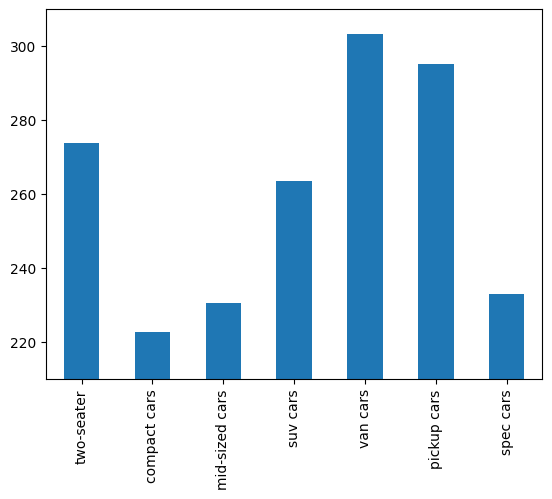

In [26]:
mean_emis_class = pd.DataFrame([
    np.mean(ndarray_two_seater_cars('EMISSIONS')),
    np.mean(ndarray_compact_cars('EMISSIONS')),
    np.mean(ndarray_mid_sized_cars('EMISSIONS')),
    np.mean(ndarray_suv_cars('EMISSIONS')),
    np.mean(ndarray_van_cars('EMISSIONS')),
    np.mean(ndarray_pickup_cars('EMISSIONS')),
    np.mean(ndarray_spec_cars('EMISSIONS'))
], index=['two-seater', 'compact cars', 'mid-sized cars', 'suv cars', 'van cars', 'pickup cars', 'spec cars'])

print(mean_emis_class)
mean_emis_class.plot.bar()
plt.legend().remove()
plt.ylim(210,310)

* Suma emisiilor dupa clase

In [51]:
def np_sum_ndarray_groupby_emis_class(): # cu ndarray
    np.sum(ndarray_group_by_vehicle_class('EMISSIONS', 'TWO-SEATER'))
    np.sum(ndarray_group_by_vehicle_class('EMISSIONS', 'COMPACT'))
    np.sum(ndarray_group_by_vehicle_class('EMISSIONS', 'MID-SIZE'))
    np.sum(ndarray_group_by_vehicle_class('EMISSIONS', 'SUV'))
    np.sum(ndarray_group_by_vehicle_class('EMISSIONS', 'VAN'))
    np.sum(ndarray_group_by_vehicle_class('EMISSIONS', 'PICKUP TRUCK'))
    np.sum(ndarray_group_by_vehicle_class('EMISSIONS', 'SPECIAL PURPOSE VEHICLE'))

def np_sum_ser_groupby_emis_class(): # cu serii
    np.sum(ser_group_by_vehicle_class('EMISSIONS', 'TWO-SEATER'))
    np.sum(ser_group_by_vehicle_class('EMISSIONS', 'COMPACT'))
    np.sum(ser_group_by_vehicle_class('EMISSIONS', 'MID-SIZE'))
    np.sum(ser_group_by_vehicle_class('EMISSIONS', 'SUV'))
    np.sum(ser_group_by_vehicle_class('EMISSIONS', 'VAN'))
    np.sum(ser_group_by_vehicle_class('EMISSIONS', 'PICKUP TRUCK'))
    np.sum(ser_group_by_vehicle_class('EMISSIONS', 'SPECIAL PURPOSE VEHICLE'))

def np_sum_ser_pandas_isin_emis_class(): # cu serii
    np.sum(ser_pandas_isin_two_seater_cars('EMISSIONS'))
    np.sum(ser_pandas_isin_compact_cars('EMISSIONS'))
    np.sum(ser_pandas_isin_mid_sized_cars('EMISSIONS'))
    np.sum(ser_pandas_isin_suv_cars('EMISSIONS'))
    np.sum(ser_pandas_isin_van_cars('EMISSIONS'))
    np.sum(ser_pandas_isin_pickup_cars('EMISSIONS'))
    np.sum(ser_pandas_isin_spec_cars('EMISSIONS'))

def np_sum_emis_class():
    np.sum(ndarray_two_seater_cars('EMISSIONS'))
    np.sum(ndarray_compact_cars('EMISSIONS'))
    np.sum(ndarray_mid_sized_cars('EMISSIONS'))
    np.sum(ndarray_suv_cars('EMISSIONS'))
    np.sum(ndarray_van_cars('EMISSIONS'))
    np.sum(ndarray_pickup_cars('EMISSIONS'))
    np.sum(ndarray_spec_cars('EMISSIONS'))

def py_sum_emis_class():
    sum(list_two_seater_cars('EMISSIONS'))
    sum(list_compact_cars('EMISSIONS'))
    sum(list_mid_sized_cars('EMISSIONS'))
    sum(list_suv_cars('EMISSIONS'))
    sum(list_van_cars('EMISSIONS'))
    sum(list_pickup_cars('EMISSIONS'))
    sum(list_spec_cars('EMISSIONS'))


tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_ndarray_groupby_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Sum NDArray GroupBy Size: {memory_size} \n NumPy Sum NDArray GroupBy Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_ser_groupby_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Sum ser GroupBy Size: {memory_size} \n NumPy Sum ser GroupBy Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_ser_pandas_isin_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Sum ser Pandas (isin) Size: {memory_size} \n NumPy Sum ser Pandas (isin) Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("py_sum_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" Python Sum Size: {memory_size} \n Python Sum Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Sum Size: {memory_size} \n NumPy Sum Peak: {memory_peak} \n Exec. Time: {exec_time}")
tracemalloc.stop()

 NumPy Sum NDArray GroupBy Size: 3914 
 NumPy Sum NDArray GroupBy Peak: 909877 
 Exec. Time: 0.03993369999807328
----------------------------------------------------------------------------------
 NumPy Sum ser GroupBy Size: 5951 
 NumPy Sum ser GroupBy Peak: 911678 
 Exec. Time: 0.07511900000099558
----------------------------------------------------------------------------------
 NumPy Sum ser Pandas (isin) Size: 4820 
 NumPy Sum ser Pandas (isin) Peak: 176978 
 Exec. Time: 0.04611609999847133
----------------------------------------------------------------------------------
 Python Sum Size: 3040 
 Python Sum Peak: 1181037 
 Exec. Time: 1.0223175999999512
----------------------------------------------------------------------------------
 NumPy Sum Size: 2656 
 NumPy Sum Peak: 1181757 
 Exec. Time: 0.7689604000042891


* grafic

                      0
two-seater       359385
compact cars    1365068
mid-sized cars  1319630
suv cars        1453668
van cars         315043
pickup cars      801183
spec cars         26567


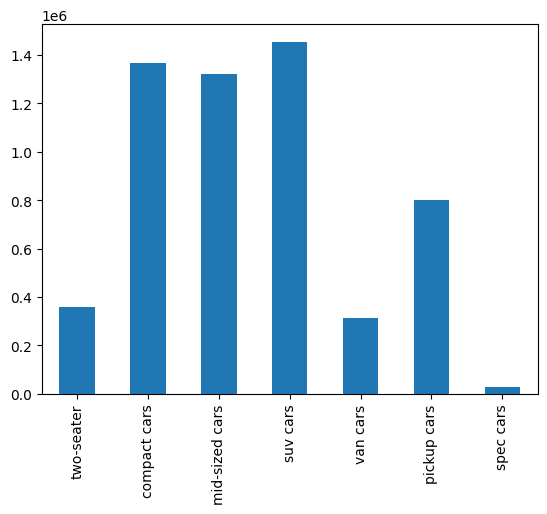

In [52]:
sum_emis_class = pd.DataFrame([
    np.sum(ndarray_two_seater_cars('EMISSIONS')),
    np.sum(ndarray_compact_cars('EMISSIONS')),
    np.sum(ndarray_mid_sized_cars('EMISSIONS')),
    np.sum(ndarray_suv_cars('EMISSIONS')),
    np.sum(ndarray_van_cars('EMISSIONS')),
    np.sum(ndarray_pickup_cars('EMISSIONS')),
    np.sum(ndarray_spec_cars('EMISSIONS'))
], index=['two-seater', 'compact cars', 'mid-sized cars', 'suv cars', 'van cars', 'pickup cars', 'spec cars'])

print(sum_emis_class)
sum_emis_class.plot.bar()
plt.legend().remove()
#plt.ylim(210,310)

* Maximul emisiilor dupa clase

In [56]:
def np_max_ndarray_groupby_emis_class(): # cu ndarray
    np.max(ndarray_group_by_vehicle_class('EMISSIONS', 'TWO-SEATER'))
    np.max(ndarray_group_by_vehicle_class('EMISSIONS', 'COMPACT'))
    np.max(ndarray_group_by_vehicle_class('EMISSIONS', 'MID-SIZE'))
    np.max(ndarray_group_by_vehicle_class('EMISSIONS', 'SUV'))
    np.max(ndarray_group_by_vehicle_class('EMISSIONS', 'VAN'))
    np.max(ndarray_group_by_vehicle_class('EMISSIONS', 'PICKUP TRUCK'))
    np.max(ndarray_group_by_vehicle_class('EMISSIONS', 'SPECIAL PURPOSE VEHICLE'))

def np_max_ser_groupby_emis_class(): # cu serii
    np.max(ser_group_by_vehicle_class('EMISSIONS', 'TWO-SEATER'))
    np.max(ser_group_by_vehicle_class('EMISSIONS', 'COMPACT'))
    np.max(ser_group_by_vehicle_class('EMISSIONS', 'MID-SIZE'))
    np.max(ser_group_by_vehicle_class('EMISSIONS', 'SUV'))
    np.max(ser_group_by_vehicle_class('EMISSIONS', 'VAN'))
    np.max(ser_group_by_vehicle_class('EMISSIONS', 'PICKUP TRUCK'))
    np.max(ser_group_by_vehicle_class('EMISSIONS', 'SPECIAL PURPOSE VEHICLE'))

def np_max_ser_pandas_isin_emis_class(): # cu serii
    np.max(ser_pandas_isin_two_seater_cars('EMISSIONS'))
    np.max(ser_pandas_isin_compact_cars('EMISSIONS'))
    np.max(ser_pandas_isin_mid_sized_cars('EMISSIONS'))
    np.max(ser_pandas_isin_suv_cars('EMISSIONS'))
    np.max(ser_pandas_isin_van_cars('EMISSIONS'))
    np.max(ser_pandas_isin_pickup_cars('EMISSIONS'))
    np.max(ser_pandas_isin_spec_cars('EMISSIONS'))

def np_max_emis_class():
    np.max(ndarray_two_seater_cars('EMISSIONS'))
    np.max(ndarray_compact_cars('EMISSIONS'))
    np.max(ndarray_mid_sized_cars('EMISSIONS'))
    np.max(ndarray_suv_cars('EMISSIONS'))
    np.max(ndarray_van_cars('EMISSIONS'))
    np.max(ndarray_pickup_cars('EMISSIONS'))
    np.max(ndarray_spec_cars('EMISSIONS'))

def py_max_emis_class():
    max(list_two_seater_cars('EMISSIONS'))
    max(list_compact_cars('EMISSIONS'))
    max(list_mid_sized_cars('EMISSIONS'))
    max(list_suv_cars('EMISSIONS'))
    max(list_van_cars('EMISSIONS'))
    max(list_pickup_cars('EMISSIONS'))
    max(list_spec_cars('EMISSIONS'))

tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_max_ndarray_groupby_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Max NDArray GroupBy Size: {memory_size} \n NumPy Max NDArray GroupBy Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_max_ser_groupby_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Max ser GroupBy Size: {memory_size} \n NumPy Max ser GroupBy Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_max_ser_pandas_isin_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Max ser Pandas (isin) Size: {memory_size} \n NumPy Max ser Pandas (isin) Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("py_max_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"Python Max Size: {memory_size} \nPython Max Peak: {memory_peak} \nExec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_max_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f"NumPy Max Size: {memory_size} \nNumPy Max Peak: {memory_peak} \nExec. Time: {exec_time}")
tracemalloc.stop()

 NumPy Max NDArray GroupBy Size: 3905 
 NumPy Max NDArray GroupBy Peak: 909868 
Exec. Time: 0.05323250000947155
----------------------------------------------------------------------------------
 NumPy Max ser GroupBy Size: 4579 
 NumPy Max ser GroupBy Peak: 910938 
Exec. Time: 0.06764169999223668
----------------------------------------------------------------------------------
 NumPy Max ser Pandas (isin) Size: 4935 
 NumPy Max ser Pandas (isin) Peak: 177434 
Exec. Time: 0.04302710000774823
----------------------------------------------------------------------------------
Python Max Size: 3040 
Python Max Peak: 1182859 
Exec. Time: 0.7596211000054609
----------------------------------------------------------------------------------
NumPy Max Size: 2656 
NumPy Max Peak: 1180709 
Exec. Time: 0.5888859999977285


* grafic

                  0
two-seater      608
compact cars    522
mid-sized cars  465
suv cars        476
van cars        465
pickup cars     513
spec cars       298


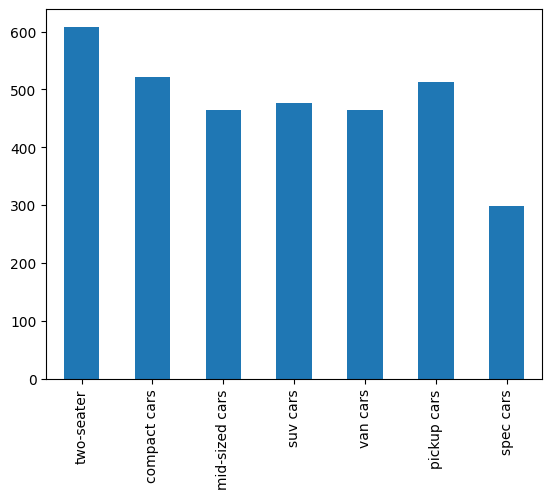

In [57]:
max_emis_class = pd.DataFrame([
    np.max(ndarray_two_seater_cars('EMISSIONS')),
    np.max(ndarray_compact_cars('EMISSIONS')),
    np.max(ndarray_mid_sized_cars('EMISSIONS')),
    np.max(ndarray_suv_cars('EMISSIONS')),
    np.max(ndarray_van_cars('EMISSIONS')),
    np.max(ndarray_pickup_cars('EMISSIONS')),
    np.max(ndarray_spec_cars('EMISSIONS'))],
    index=['two-seater', 'compact cars', 'mid-sized cars', 'suv cars', 'van cars', 'pickup cars', 'spec cars'])

print(max_emis_class)
max_emis_class.plot.bar()
plt.legend().remove()

* Minimul emisiilor dupa clase

In [58]:
def np_min_ndarray_groupby_emis_class(): # cu ndarray
    np.min(ndarray_group_by_vehicle_class('EMISSIONS', 'TWO-SEATER'))
    np.min(ndarray_group_by_vehicle_class('EMISSIONS', 'COMPACT'))
    np.min(ndarray_group_by_vehicle_class('EMISSIONS', 'MID-SIZE'))
    np.min(ndarray_group_by_vehicle_class('EMISSIONS', 'SUV'))
    np.min(ndarray_group_by_vehicle_class('EMISSIONS', 'VAN'))
    np.min(ndarray_group_by_vehicle_class('EMISSIONS', 'PICKUP TRUCK'))
    np.min(ndarray_group_by_vehicle_class('EMISSIONS', 'SPECIAL PURPOSE VEHICLE'))

def np_min_ser_groupby_emis_class(): # cu serii
    np.min(ser_group_by_vehicle_class('EMISSIONS', 'TWO-SEATER'))
    np.min(ser_group_by_vehicle_class('EMISSIONS', 'COMPACT'))
    np.min(ser_group_by_vehicle_class('EMISSIONS', 'MID-SIZE'))
    np.min(ser_group_by_vehicle_class('EMISSIONS', 'SUV'))
    np.min(ser_group_by_vehicle_class('EMISSIONS', 'VAN'))
    np.min(ser_group_by_vehicle_class('EMISSIONS', 'PICKUP TRUCK'))
    np.min(ser_group_by_vehicle_class('EMISSIONS', 'SPECIAL PURPOSE VEHICLE'))

def np_min_ser_pandas_isin_emis_class(): # cu serii
    np.min(ser_pandas_isin_two_seater_cars('EMISSIONS'))
    np.min(ser_pandas_isin_compact_cars('EMISSIONS'))
    np.min(ser_pandas_isin_mid_sized_cars('EMISSIONS'))
    np.min(ser_pandas_isin_suv_cars('EMISSIONS'))
    np.min(ser_pandas_isin_van_cars('EMISSIONS'))
    np.min(ser_pandas_isin_pickup_cars('EMISSIONS'))
    np.min(ser_pandas_isin_spec_cars('EMISSIONS'))

def np_min_emis_class():
    np.min(ndarray_two_seater_cars('EMISSIONS'))
    np.min(ndarray_compact_cars('EMISSIONS'))
    np.min(ndarray_mid_sized_cars('EMISSIONS'))
    np.min(ndarray_suv_cars('EMISSIONS'))
    np.min(ndarray_van_cars('EMISSIONS'))
    np.min(ndarray_pickup_cars('EMISSIONS'))
    np.min(ndarray_spec_cars('EMISSIONS'))

def py_min_emis_class():
    min(list_two_seater_cars('EMISSIONS'))
    min(list_compact_cars('EMISSIONS'))
    min(list_mid_sized_cars('EMISSIONS'))
    min(list_suv_cars('EMISSIONS'))
    min(list_van_cars('EMISSIONS'))
    min(list_pickup_cars('EMISSIONS'))
    min(list_spec_cars('EMISSIONS'))

tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_min_ndarray_groupby_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Min NDArray GroupBy Size: {memory_size} \n NumPy Min NDArray GroupBy Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_min_ser_groupby_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Min ser GroupBy Size: {memory_size} \n NumPy Min ser GroupBy Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_min_ser_pandas_isin_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Min ser Pandas (isin) Size: {memory_size} \n NumPy Min ser Pandas (isin) Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("py_min_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" Python Min Size: {memory_size} \n Python Min Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_min_emis_class()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Min Size: {memory_size} \n NumPy Min Peak: {memory_peak} \n Exec. Time: {exec_time}")
tracemalloc.stop()

 NumPy Min NDArray GroupBy Size: 3346 
 NumPy Min NDArray GroupBy Peak: 908845 
 Exec. Time: 0.06434700000681914
----------------------------------------------------------------------------------
 NumPy Min ser GroupBy Size: 5723 
 NumPy Min ser GroupBy Peak: 911658 
 Exec. Time: 0.05499760000384413
----------------------------------------------------------------------------------
 NumPy Min ser Pandas (isin) Size: 3755 
 NumPy Min ser Pandas (isin) Peak: 177434 
 Exec. Time: 0.03893110000353772
----------------------------------------------------------------------------------
 Python Min Size: 2704 
 Python Min Peak: 1182343 
 Exec. Time: 0.6816905000014231
----------------------------------------------------------------------------------
 NumPy Min Size: 2656 
 NumPy Min Peak: 1181869 
 Exec. Time: 0.5745677000086289


* grafic

                  0
two-seater       83
compact cars     83
mid-sized cars   87
suv cars        128
van cars        153
pickup cars     147
spec cars       184


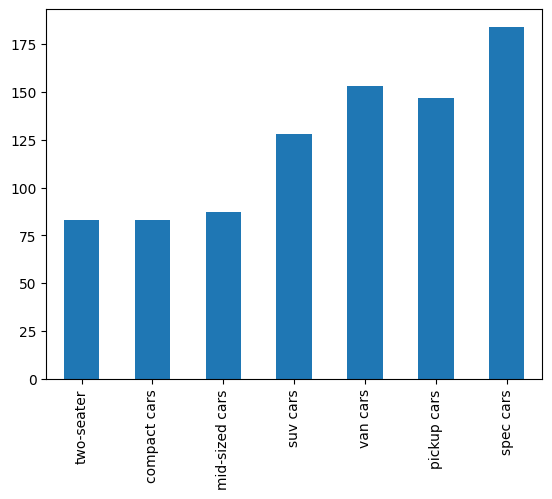

In [32]:
min_emis_class = pd.DataFrame([
    np.min(ndarray_two_seater_cars('EMISSIONS')),
    np.min(ndarray_compact_cars('EMISSIONS')),
    np.min(ndarray_mid_sized_cars('EMISSIONS')),
    np.min(ndarray_suv_cars('EMISSIONS')),
    np.min(ndarray_van_cars('EMISSIONS')),
    np.min(ndarray_pickup_cars('EMISSIONS')),
    np.min(ndarray_spec_cars('EMISSIONS'))],
    index=['two-seater', 'compact cars', 'mid-sized cars', 'suv cars', 'van cars', 'pickup cars', 'spec cars'])

print(min_emis_class)
min_emis_class.plot.bar()
plt.legend().remove()

## Difera emisiile de tipul de carburant ?

suma, media, numarul de masini

In [109]:
type_fuel_indexed_dataset = dataset.set_index('FUEL')
type_fuel_indexed_dataset.head()

,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
FUEL,,,,,,,,,,,,
X,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,9.2,6.7,8.1,35,186
X,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,8.5,6.5,7.6,37,175
Z,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,12.2,7.4,10.0,28,230
Z,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,13.4,9.2,11.5,25,264
X,2000,ACURA,INTEGRA,COMPACT,1.8,4,A4,10.0,7.0,8.6,33,198


In [83]:
def ser_group_by_type_fuel(fuel_type, need_column):
    return dataset.groupby('FUEL')[need_column].get_group(fuel_type)

def ndarray_group_by_type_fuel(fuel_type, need_column):
    return np.array(dataset.groupby('FUEL')[need_column].get_group(fuel_type))

In [84]:
def ndarray_fuel_type(fuel_type, need_column):
    return np.array(dataset.loc[(dataset['FUEL'] == fuel_type), need_column])

def list_fuel_type(fuel_type, need_column):
    return list(dataset.loc[(dataset['FUEL'] == fuel_type), need_column])

def ser_fuel_type(fuel_type, need_column):
    return dataset.loc[(dataset['FUEL'] == fuel_type), need_column]

* suma

In [111]:
def np_sum_ser_indexed_type_fuel():
    np.sum(type_fuel_indexed_dataset.loc['X','EMISSIONS'])
    np.sum(type_fuel_indexed_dataset.loc['Z','EMISSIONS'])
    np.sum(type_fuel_indexed_dataset.loc['D','EMISSIONS'])
    np.sum(type_fuel_indexed_dataset.loc['E','EMISSIONS'])
    np.sum(type_fuel_indexed_dataset.loc['N','EMISSIONS'])

def np_sum_ndarray_groupby_emis_type_fuel():
    np.sum(ndarray_group_by_type_fuel('X','EMISSIONS'))
    np.sum(ndarray_group_by_type_fuel('Z','EMISSIONS'))
    np.sum(ndarray_group_by_type_fuel('D','EMISSIONS'))
    np.sum(ndarray_group_by_type_fuel('E','EMISSIONS'))
    np.sum(ndarray_group_by_type_fuel('N','EMISSIONS'))

def np_sum_ser_groupby_emis_type_fuel():
    np.sum(ser_group_by_type_fuel('X','EMISSIONS'))
    np.sum(ser_group_by_type_fuel('Z','EMISSIONS'))
    np.sum(ser_group_by_type_fuel('D','EMISSIONS'))
    np.sum(ser_group_by_type_fuel('E','EMISSIONS'))
    np.sum(ser_group_by_type_fuel('N','EMISSIONS'))

def np_sum_ser_emis_fuel_type():
    np.sum(ser_fuel_type('X','EMISSIONS'))
    np.sum(ser_fuel_type('Z','EMISSIONS'))
    np.sum(ser_fuel_type('D','EMISSIONS'))
    np.sum(ser_fuel_type('E','EMISSIONS'))
    np.sum(ser_fuel_type('N','EMISSIONS'))

def np_sum_emis_fuel_type():
    np.sum(ndarray_fuel_type('X','EMISSIONS'))
    np.sum(ndarray_fuel_type('Z','EMISSIONS'))
    np.sum(ndarray_fuel_type('D','EMISSIONS'))
    np.sum(ndarray_fuel_type('E','EMISSIONS'))
    np.sum(ndarray_fuel_type('N','EMISSIONS'))

def py_list_sum_emis_fuel_type():
    sum(list_fuel_type('X','EMISSIONS'))
    sum(list_fuel_type('Z','EMISSIONS'))
    sum(list_fuel_type('D','EMISSIONS'))
    sum(list_fuel_type('E','EMISSIONS'))
    sum(list_fuel_type('N','EMISSIONS'))

tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_ser_indexed_type_fuel()", globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Sum ser Indexed Size: {memory_size} \n NumPy Sum ser Indexed Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_ndarray_groupby_emis_type_fuel()", globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Sum NDArray GroupBy Size: {memory_size} \n NumPy Sum NDArray GroupBy Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_ser_groupby_emis_type_fuel()", globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Sum ser GroupBy Size: {memory_size} \n NumPy Sum ser GroupBy Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_ser_emis_fuel_type()", globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Sum ser Size: {memory_size} \n NumPy Sum ser Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("py_list_sum_emis_fuel_type()", globals=globals(),number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" Python Sum Size: {memory_size} \n Python Sum Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_sum_emis_fuel_type()", globals=globals(), number=10)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Sum Size: {memory_size} \n NumPy Sum Peak: {memory_peak} \n Exec. Time: {exec_time}")
tracemalloc.stop()

 NumPy Sum ser Indexed Size: 22294 
 NumPy Sum ser Indexed Peak: 1373312 
 Exec. Time: 0.14893039999878965
----------------------------------------------------------------------------------
 NumPy Sum NDArray GroupBy Size: 4470 
 NumPy Sum NDArray GroupBy Peak: 910541 
 Exec. Time: 0.18855920000351034
----------------------------------------------------------------------------------
 NumPy Sum ser GroupBy Size: 7414 
 NumPy Sum ser GroupBy Peak: 913481 
 Exec. Time: 0.2639574999921024
----------------------------------------------------------------------------------
 NumPy Sum ser Size: 2344 
 NumPy Sum ser Peak: 313679 
 Exec. Time: 0.1430772000021534
----------------------------------------------------------------------------------
 Python Sum Size: 2140 
 Python Sum Peak: 411020 
 Exec. Time: 0.46482589999504853
----------------------------------------------------------------------------------
 NumPy Sum Size: 1553 
 NumPy Sum Peak: 312884 
 Exec. Time: 0.13026930000341963


* grafic

                    0
Benzina       2840599
Benzina Prem  2427515
Diesel          72316
Ethanol(e85)   289790
Gaz Natural     10324


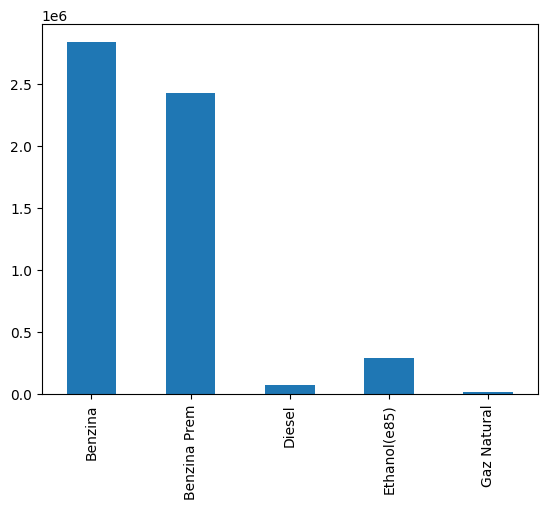

In [90]:
sum_emis_type_fuel = pd.DataFrame([
    np.sum(ndarray_fuel_type('X','EMISSIONS')),
    np.sum(ndarray_fuel_type('Z','EMISSIONS')),
    np.sum(ndarray_fuel_type('D','EMISSIONS')),
    np.sum(ndarray_fuel_type('E','EMISSIONS')),
    np.sum(ndarray_fuel_type('N','EMISSIONS'))
], index=['Benzina', 'Benzina Prem', 'Diesel', 'Ethanol(e85)', 'Gaz Natural'])

print(sum_emis_type_fuel)
sum_emis_type_fuel.plot.bar()
plt.legend().remove()

* media

In [92]:
def np_mean_ndarray_groupby_emis_type_fuel():
    np.mean(ndarray_group_by_type_fuel('X','EMISSIONS'))
    np.mean(ndarray_group_by_type_fuel('Z','EMISSIONS'))
    np.mean(ndarray_group_by_type_fuel('D','EMISSIONS'))
    np.mean(ndarray_group_by_type_fuel('E','EMISSIONS'))
    np.mean(ndarray_group_by_type_fuel('N','EMISSIONS'))

def np_mean_ser_groupby_emis_type_fuel():
    np.mean(ser_group_by_type_fuel('X','EMISSIONS'))
    np.mean(ser_group_by_type_fuel('Z','EMISSIONS'))
    np.mean(ser_group_by_type_fuel('D','EMISSIONS'))
    np.mean(ser_group_by_type_fuel('E','EMISSIONS'))
    np.mean(ser_group_by_type_fuel('N','EMISSIONS'))

def np_mean_ndarray_emis_fuel_type():
    np.mean(ndarray_fuel_type('X','EMISSIONS'))
    np.mean(ndarray_fuel_type('Z','EMISSIONS'))
    np.mean(ndarray_fuel_type('D','EMISSIONS'))
    np.mean(ndarray_fuel_type('E','EMISSIONS'))
    np.mean(ndarray_fuel_type('N','EMISSIONS'))

def py_mean_ser_emis_fuel_type():
    ser_fuel_type('X','EMISSIONS').mean()
    ser_fuel_type('Z','EMISSIONS').mean()
    ser_fuel_type('D','EMISSIONS').mean()
    ser_fuel_type('E','EMISSIONS').mean()
    ser_fuel_type('N','EMISSIONS').mean()

def my_mean_list_emis_fuel_type():
    my_mean(list_fuel_type('X','EMISSIONS'))
    my_mean(list_fuel_type('Z','EMISSIONS'))
    my_mean(list_fuel_type('D','EMISSIONS'))
    my_mean(list_fuel_type('E','EMISSIONS'))
    my_mean(list_fuel_type('N','EMISSIONS'))


tracemalloc.start()
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ndarray_groupby_emis_type_fuel()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Mean NDArray GroupBy Size: {memory_size} \n NumPy Mean NDArray GroupBy Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ser_groupby_emis_type_fuel()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Mean ser GroupBy Size: {memory_size} \n NumPy Mean ser GroupBy Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("py_mean_ser_emis_fuel_type()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" Python Mean Size: {memory_size} \n Python Mean Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("my_mean_list_emis_fuel_type()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" My Mean Size: {memory_size} \n My Mean Peak: {memory_peak} \n Exec. Time: {exec_time}")
print('----------------------------------------------------------------------------------')
tracemalloc.clear_traces()
exec_time = timeit.timeit("np_mean_ndarray_emis_fuel_type()", globals=globals(), number=1)
memory_size, memory_peak = tracemalloc.get_traced_memory()
print(f" NumPy Mean Size: {memory_size} \n NumPy Mean Peak: {memory_peak} \n Exec. Time: {exec_time}")
tracemalloc.stop()

 NumPy Mean NDArray GroupBy Size: 2546 
 NumPy Mean NDArray GroupBy Peak: 907914 
 Exec. Time: 0.04191609998815693
----------------------------------------------------------------------------------
 NumPy Mean ser GroupBy Size: 3827 
 NumPy Mean ser GroupBy Peak: 909039 
 Exec. Time: 0.045671999992919154
----------------------------------------------------------------------------------
 Python Mean Size: 1121 
 Python Mean Peak: 311033 
 Exec. Time: 0.03997199999867007
----------------------------------------------------------------------------------
 My Mean Size: 1401 
 My Mean Peak: 408690 
 Exec. Time: 0.10208430000056978
----------------------------------------------------------------------------------
 NumPy Mean Size: 1492 
 NumPy Mean Peak: 311037 
 Exec. Time: 0.019624700013082474


* grafic

                       0
Benzina       240.280748
Benzina Prem  260.574818
Diesel        230.305732
Ethanol(e85)  270.578898
Gaz Natural   312.848485


(220.0, 320.0)

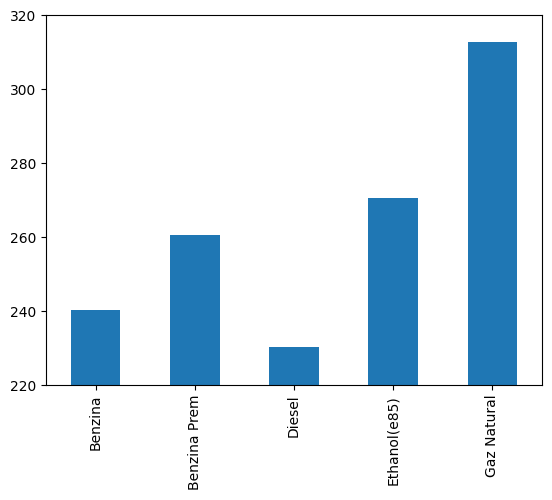

In [93]:
mean_emis_type_fuel = pd.DataFrame([
    np.mean(ndarray_fuel_type('X','EMISSIONS')),
    np.mean(ndarray_fuel_type('Z','EMISSIONS')),
    np.mean(ndarray_fuel_type('D','EMISSIONS')),
    np.mean(ndarray_fuel_type('E','EMISSIONS')),
    np.mean(ndarray_fuel_type('N','EMISSIONS'))
], index=['Benzina', 'Benzina Prem', 'Diesel', 'Ethanol(e85)', 'Gaz Natural'])

print(mean_emis_type_fuel)
mean_emis_type_fuel.plot.bar()
plt.legend().remove()
plt.ylim(220,320)

In [94]:
print(len(ndarray_fuel_type('X','EMISSIONS')))
print(len(ndarray_fuel_type('Z','EMISSIONS')))
print(len(ndarray_fuel_type('D','EMISSIONS')))
print(len(ndarray_fuel_type('E','EMISSIONS')))
print(len(ndarray_fuel_type('N','EMISSIONS')))

11822
9316
314
1071
33
